# makemore Part 4 — Becoming a Backprop Ninja

This notebook teaches **manual backpropagation** by deriving and implementing
gradients by hand, then verifying them against PyTorch autograd.

The notebook is structured as four progressive exercises:

| Exercise | What you implement |
|----------|-------------------|
| **1** | Full manual backward through every intermediate variable in the forward pass |
| **2** | Fused cross-entropy gradient — one closed-form expression instead of 7 steps |
| **3** | Fused BatchNorm gradient — one closed-form expression instead of 9 steps |
| **4** | Full training loop using only your manual gradients (no `loss.backward()`) |

**Key insight**: autograd is just the chain rule applied mechanically to each
primitive operation.  Once you understand each rule, you can fuse adjacent
operations into a single, faster gradient expression.

**Notation used throughout:**
- `dX` means `dL/dX` — the partial derivative of the scalar loss `L` w.r.t. tensor `X`
- `n` = batch size
- `⊙` = element-wise multiplication

## 1. Imports

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

%matplotlib inline

In [2]:
import mlflow, os

if not os.path.exists('names.txt') and os.path.exists('../names.txt'):
    os.chdir('..')

os.makedirs('checkpoints', exist_ok=True)
mlflow.set_experiment('makemore')
_mlflow_run = mlflow.start_run(run_name='part4-backprop-ninja')
print(f'MLflow run started  id={_mlflow_run.info.run_id}')

MLflow run started  id=7dbfbde539e84230b65b9a1514b1bd96


## 2. Data Loading, Vocabulary & Dataset

Identical setup to Parts 2 & 3 — `'.'` (index 0) is the boundary token,
`block_size = 3` characters of context predict the next character.

In [3]:
words = open('names.txt', 'r').read().splitlines()
print(f'{len(words):,} words   max length: {max(len(w) for w in words)}')

chars = sorted(list(set(''.join(words))))
stoi  = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'vocab_size = {vocab_size}')

32,033 words   max length: 15
vocab_size = 27


In [4]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 3. Gradient Comparison Utility

`cmp(label, manual_grad, tensor)` checks three things after `loss.backward()`
has populated `tensor.grad`:

| Check | Meaning |
|-------|---------|
| **exact** | `manual_grad == tensor.grad` bit-for-bit (rarely true due to floating-point order) |
| **approximate** | `torch.allclose` with default tolerances (`rtol=1e-5, atol=1e-8`) |
| **maxdiff** | largest absolute deviation between the two — should be < 1e-7 |

In [5]:
def cmp(s, dt, t):
    """Compare manual gradient dt against PyTorch-computed t.grad."""
    ex      = torch.all(dt == t.grad).item()
    app     = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

## 4. Model Initialization

For the gradient-checking exercises we use a **small network** (`n_hidden = 64`)
and **deliberately non-standard parameter initialization**.

Why non-standard init?
- If we initialized `bngain = ones` and `bnbias = zeros` (the standard defaults),
  many gradient components would be exactly zero, masking bugs in the backward pass.
- Random initialization of `bngain` and `bnbias` means every gradient is non-trivial
  and a mismatch is easy to detect.

`b1` is included even though BatchNorm renders it redundant — again, purely to
give the gradient checker something non-trivial to verify.

In [6]:
n_embd   = 10   # character embedding dimension
n_hidden = 64   # small network for gradient checking

g = torch.Generator().manual_seed(2147483647)

C      = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1 — Kaiming init for tanh
W1     = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size) ** 0.5
b1     = torch.randn(n_hidden,                        generator=g) * 0.1   # kept for testing; BN makes it redundant
# Layer 2 — small init so initial logits are near-zero
W2     = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2     = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm — non-standard init to make gradient checking non-trivial
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0   # γ ≈ 1 with small noise
bnbias = torch.randn((1, n_hidden)) * 0.1          # β ≈ 0 with small noise

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(f'Total parameters: {sum(p.nelement() for p in parameters):,}')
for p in parameters:
    p.requires_grad = True

Total parameters: 4,137


## 5. Single Mini-batch for Gradient Checking

Exercises 1–3 operate on a **fixed single mini-batch** of 32 examples.
This keeps the computation deterministic and fast while we verify gradients.

In [7]:
batch_size = 32
n = batch_size   # shorthand used throughout the backward pass derivations

ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]
print(f'Xb: {tuple(Xb.shape)}   Yb: {tuple(Yb.shape)}')

Xb: (32, 3)   Yb: (32,)


## 6. "Chunkated" Forward Pass

We decompose every compound operation into its **atomic primitives**,
assigning each intermediate result to a named variable.
This one-operation-per-line style makes the corresponding backward pass
mechanical: each line needs exactly one gradient rule.

**Forward pass pipeline:**

```
Xb
 └─ emb     = C[Xb]                         embedding lookup
 └─ embcat  = emb.view(n, -1)               flatten context window
 └─ hprebn  = embcat @ W1 + b1              linear pre-BN
    ├─ bnmeani = mean(hprebn, axis=0)        batch mean  (shape: 1×H)
    ├─ bndiff  = hprebn − bnmeani            centered
    ├─ bndiff2 = bndiff²                     squared deviations
    ├─ bnvar   = sum(bndiff2)/(n−1)          variance  (Bessel's correction)
    ├─ bnvar_inv = (bnvar + ε)^{−0.5}        inverse std
    ├─ bnraw   = bndiff ⊙ bnvar_inv          normalized
    └─ hpreact = bngain ⊙ bnraw + bnbias     scaled & shifted
 └─ h       = tanh(hpreact)                 non-linearity
 └─ logits  = h @ W2 + b2                   output layer
    ├─ logit_maxes  = max(logits, axis=1)    for numerical stability
    ├─ norm_logits  = logits − logit_maxes   shifted logits
    ├─ counts       = exp(norm_logits)       unnormalized probs
    ├─ counts_sum   = sum(counts, axis=1)    normalizing constant
    ├─ counts_sum_inv = counts_sum^{−1}      reciprocal
    ├─ probs        = counts ⊙ counts_sum_inv softmax probabilities
    ├─ logprobs     = log(probs)             log-probabilities
    └─ loss         = −mean(logprobs[Yb])    NLL loss
```

> **Note on Bessel's correction**: `bnvar` divides by `n−1` (unbiased sample
> variance) rather than `n`.  This matters for the backward pass because
> the derivative picks up a factor of `1/(n−1)` instead of `1/n`.

In [ ]:
# Embedding
emb    = C[Xb]                                   # (n, block_size, n_embd)
embcat = emb.view(emb.shape[0], -1)              # (n, block_size * n_embd)

# Linear layer 1
hprebn = embcat @ W1 + b1                        # (n, n_hidden)  pre-BN activations

# Batch Normalization (expanded into primitives)
bnmeani    = 1/n * hprebn.sum(0, keepdim=True)   # (1, n_hidden)  batch mean
bndiff     = hprebn - bnmeani                    # (n, n_hidden)  mean-centered
bndiff2    = bndiff ** 2                         # (n, n_hidden)  squared deviations
bnvar      = 1/(n-1) * bndiff2.sum(0, keepdim=True)  # (1, n_hidden) variance (Bessel)
bnvar_inv  = (bnvar + 1e-5) ** -0.5             # (1, n_hidden)  inverse std
bnraw      = bndiff * bnvar_inv                  # (n, n_hidden)  normalized
hpreact    = bngain * bnraw + bnbias             # (n, n_hidden)  scaled & shifted

# Non-linearity
h = torch.tanh(hpreact)                          # (n, n_hidden)

# Linear layer 2
logits = h @ W2 + b2                             # (n, vocab_size)

# Cross-entropy loss (expanded into primitives)
logit_maxes   = logits.max(1, keepdim=True).values   # (n, 1)  for numerical stability
norm_logits   = logits - logit_maxes                 # (n, vocab_size)  shifted
counts        = norm_logits.exp()                    # (n, vocab_size)  unnormalized
counts_sum    = counts.sum(1, keepdims=True)         # (n, 1)
counts_sum_inv = counts_sum ** -1                    # (n, 1)  use **-1, not 1/ for exact backprop
probs         = counts * counts_sum_inv              # (n, vocab_size)  softmax
logprobs      = probs.log()                          # (n, vocab_size)
loss          = -logprobs[range(n), Yb].mean()       # scalar

# PyTorch backward (reference for gradient checking)
for p in parameters:
    p.grad = None
# Retain all intermediate gradients so cmp() can read them
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani, embcat, emb]:
    t.retain_grad()
loss.backward()
print(f'loss = {loss.item():.4f}')

loss = 3.3292


## Exercise 1 — Full Manual Backward Pass

We derive `dX` (= `dL/dX`) for **every** intermediate tensor `X`, working
backwards from the loss.  The chain rule says:

> **If** `Y = f(X)` **then** `dX = dY · (df/dX)`

Key rules used:

| Operation | Forward | Gradient rule |
|-----------|---------|---------------|
| `log` | `y = log(x)` | `dx = dy / x` |
| Index select | `y = x[i, j]` | `dx[i,j] += dy` |
| Element-wise `*` | `y = a ⊙ b` | `da = dy ⊙ b`,  `db = dy ⊙ a` |
| Sum (reduce) | `y = x.sum(dim)` | `dx = dy` broadcast back |
| `x ** k` | `y = x^k` | `dx = dy · k · x^{k-1}` |
| `exp` | `y = e^x` | `dx = dy · e^x = dy ⊙ y` |
| Matmul | `y = x @ W` | `dx = dy @ W.T`,  `dW = x.T @ dy` |
| `tanh` | `y = tanh(x)` | `dx = dy · (1 − y²)` |
| Subtract max (stable softmax) | `y = x − max(x, dim=1)` | `dx = dy`,  `d_max = −dy.sum(1)` broadcast via one-hot |

### Derivation notes

**`dlogprobs`** — Only the correct-class log-probs contribute to the loss:
```
loss = -1/n * sum_i logprobs[i, Yb[i]]
=> dlogprobs[i, j] = -1/n  if j == Yb[i],  else 0
```

**`dcounts_sum_inv`** — `probs = counts ⊙ counts_sum_inv`, broadcasting over rows:
```
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
```

**`dcounts`** — receives gradient from two paths: directly through `probs`, and
indirectly through `counts_sum → counts_sum_inv → probs`:
```
dcounts  = counts_sum_inv * dprobs           # direct path
dcounts += ones * dcounts_sum                # through counts_sum
```

**`dlogits` (through subtract-max stability trick)** — `norm_logits = logits − logit_maxes`.
The gradient of the max operation is a one-hot: it flows only through the
position that was the maximum.

**`dbnvar_inv` → `dbnvar` → `dbndiff2` → `dbndiff`** — follow the chain:
```
bnvar_inv = (bnvar + ε)^{-0.5}
  => dbnvar = -0.5 * (bnvar + ε)^{-1.5} * dbnvar_inv
bndiff2 = bndiff²  => dbndiff from this path: 2 * bndiff * dbndiff2
bnvar = sum(bndiff2) / (n-1)  => dbndiff2 = 1/(n-1) * dbnvar  (broadcast)
```

**`dhprebn` from `bndiff` and `bnmeani`** — `bndiff = hprebn − bnmeani` means
`hprebn` gets gradient directly from `dbndiff`, *plus* the mean gradient
broadcast back to every row:
```
dhprebn = dbndiff  (direct)
dhprebn += 1/n * dbnmeani  (through bnmeani = mean(hprebn))
```

**`dC`** — embedding lookup is a scatter-add: each row of `C` may be selected
multiple times in a batch.  We accumulate (+=) rather than assign.

In [ ]:
# Cross-entropy backward

# loss = -mean(logprobs[i, Yb[i]])
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0 / n

# logprobs = log(probs)  =>  dprobs = dlogprobs / probs
dprobs = (1.0 / probs) * dlogprobs

# probs = counts * counts_sum_inv  (broadcast over rows)
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts         = counts_sum_inv * dprobs                         # direct path

# counts_sum_inv = counts_sum ** -1  =>  d/dx(x^{-1}) = -x^{-2}
dcounts_sum = (-counts_sum ** -2) * dcounts_sum_inv

# counts_sum = counts.sum(1)  =>  gradient broadcasts back to all columns
dcounts += torch.ones_like(counts) * dcounts_sum

# counts = exp(norm_logits)  =>  d/dx(e^x) = e^x = counts
dnorm_logits = counts * dcounts

# norm_logits = logits - logit_maxes  =>  direct path for logits
dlogits      = dnorm_logits.clone()
# logit_maxes = max(logits, dim=1): gradient flows only through the argmax position
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=vocab_size) * dlogit_maxes

# Layer 2 backward ──
# logits = h @ W2 + b2
dh   = dlogits @ W2.T
dW2  = h.T @ dlogits
db2  = dlogits.sum(0)

# Tanh backward ─────
# h = tanh(hpreact)  =>  d/dx tanh = 1 - tanh² = 1 - h²
dhpreact = (1.0 - h ** 2) * dh

# BatchNorm backward 
# hpreact = bngain * bnraw + bnbias
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw  =  bngain * dhpreact
dbnbias =  dhpreact.sum(0, keepdim=True)

# bnraw = bndiff * bnvar_inv
dbndiff   = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)

# bnvar_inv = (bnvar + 1e-5)^{-0.5}  =>  d = -0.5 * (bnvar+ε)^{-1.5}
dbnvar = (-0.5 * (bnvar + 1e-5) ** -1.5) * dbnvar_inv

# bnvar = 1/(n-1) * bndiff2.sum(0)  (Bessel's correction)
dbndiff2 = (1.0 / (n-1)) * torch.ones_like(bndiff2) * dbnvar

# bndiff2 = bndiff²  =>  d = 2 * bndiff
dbndiff += (2 * bndiff) * dbndiff2

# bndiff = hprebn - bnmeani  =>  direct grad to hprebn
dhprebn   = dbndiff.clone()
# bnmeani = mean(hprebn) = 1/n * hprebn.sum(0)
# => gradient broadcasts back to every row of hprebn
dbnmeani  = (-dbndiff).sum(0)
dhprebn  += (1.0 / n) * torch.ones_like(hprebn) * dbnmeani

# ayer 1 backward
# hprebn = embcat @ W1 + b1
dembcat = dhprebn @ W1.T
dW1     = embcat.T @ dhprebn
db1     = dhprebn.sum(0)

# Embedding backward 
# emb.view -> embcat: reshape only, gradient is the inverse reshape
demb = dembcat.view(emb.shape)

# C[Xb] lookup: scatter-add because the same character may appear multiple times
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]
        dC[ix] += demb[k, j]

### Exercise 1 — Gradient Verification

We compare every manually computed gradient against `tensor.grad` populated by
`loss.backward()`.  All should show `approximate: True` and `maxdiff < 1e-7`.

In [10]:
cmp('logprobs',     dlogprobs,     logprobs)
cmp('probs',        dprobs,        probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum',   dcounts_sum,   counts_sum)
cmp('counts',       dcounts,       counts)
cmp('norm_logits',  dnorm_logits,  norm_logits)
cmp('logit_maxes',  dlogit_maxes,  logit_maxes)
cmp('logits',       dlogits,       logits)
cmp('h',            dh,            h)
cmp('W2',           dW2,           W2)
cmp('b2',           db2,           b2)
cmp('hpreact',      dhpreact,      hpreact)
cmp('bngain',       dbngain,       bngain)
cmp('bnbias',       dbnbias,       bnbias)
cmp('bnraw',        dbnraw,        bnraw)
cmp('bnvar_inv',    dbnvar_inv,    bnvar_inv)
cmp('bnvar',        dbnvar,        bnvar)
cmp('bndiff2',      dbndiff2,      bndiff2)
cmp('bndiff',       dbndiff,       bndiff)
cmp('bnmeani',      dbnmeani,      bnmeani)
cmp('hprebn',       dhprebn,       hprebn)
cmp('embcat',       dembcat,       embcat)
cmp('W1',           dW1,           W1)
cmp('b1',           db1,           b1)
cmp('emb',          demb,          emb)
cmp('C',            dC,            C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

## Exercise 2 — Fused Cross-Entropy Gradient

The 7 atomic forward steps for cross-entropy can be collapsed into a single
closed-form gradient expression.

### Derivation

Starting from the numerically stable cross-entropy:
```
loss = -1/n * sum_i log( exp(logits[i, y_i] - max_i) / sum_j exp(logits[i,j] - max_i) )
     = -1/n * sum_i (logits[i, y_i] - log(sum_j exp(logits[i,j])))
```
Taking `dL/d(logits[i, k])`:
```
= -1/n * (1{k == y_i}  -  exp(logits[i,k]) / sum_j exp(logits[i,j]))
= -1/n * (1{k == y_i}  -  softmax(logits)[i, k])
=  1/n * (softmax(logits)[i, k]  -  1{k == y_i})
```

In matrix form:
```python
dlogits = softmax(logits)          # shape (n, vocab_size)
dlogits[range(n), Yb] -= 1        # subtract 1 at the correct class
dlogits /= n                       # average over the batch
```

This is 3 lines instead of 20 — and numerically cleaner.

In [11]:
# Fused forward: F.cross_entropy handles the log-sum-exp trick internally
loss_fast = F.cross_entropy(logits, Yb)
print(f'loss_fast = {loss_fast.item():.6f}   diff from manual = {(loss_fast - loss).item():.2e}')

loss_fast = 3.329151   diff from manual = 0.00e+00


In [12]:
# Fused backward: closed-form gradient of cross-entropy w.r.t. logits
dlogits = F.softmax(logits, 1)         # softmax probabilities
dlogits[range(n), Yb] -= 1            # subtract 1 at the target class
dlogits /= n                           # normalize by batch size

cmp('logits (fused)', dlogits, logits)

logits (fused)  | exact: False | approximate: True  | maxdiff: 7.683411240577698e-09


### Gradient Visualization

The gradient matrix `dlogits` has a characteristic structure:
- Most entries are small positive values (`softmax / n`)
- The correct-class column for each row is a slightly larger **negative** value
  (`(softmax - 1) / n`)

The grayscale image makes this pattern visible — each row sums to exactly 0
because `softmax` sums to 1 and we subtract 1 once.

dlogits[0].sum() = 1.40e-09  (should be ~0)


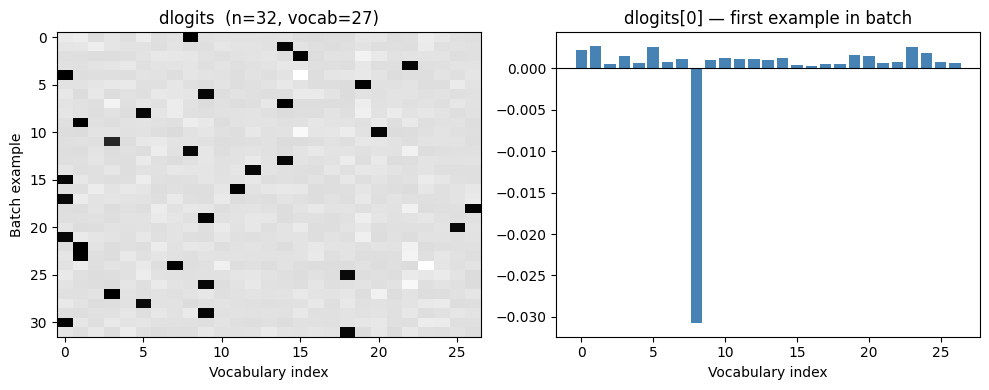

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(dlogits.detach(), cmap='gray', aspect='auto')
axes[0].set_title('dlogits  (n=32, vocab=27)')
axes[0].set_xlabel('Vocabulary index')
axes[0].set_ylabel('Batch example')

axes[1].bar(range(vocab_size), dlogits[0].detach(), color='steelblue')
axes[1].set_title('dlogits[0] — first example in batch')
axes[1].set_xlabel('Vocabulary index')
axes[1].axhline(0, color='k', lw=0.8)
print(f'dlogits[0].sum() = {dlogits[0].sum().item():.2e}  (should be ~0)')
plt.tight_layout()
plt.show()

## Exercise 3 — Fused Batch Normalization Gradient

Similarly, the 9 atomic backward steps through BatchNorm can be expressed as
one closed-form formula.

### Derivation

BN forward (Bessel-corrected variance):
```
μ = (1/n) Σ_i x_i
σ² = 1/(n-1) Σ_i (x_i - μ)²
x̂_i = (x_i - μ) / √(σ² + ε)
y_i = γ · x̂_i + β
```

Let `dy` = `dhpreact`.  Working backwards, after accounting for all the
interdependencies (μ and σ both depend on every x_i, so there are
multiple gradient paths):

```
dx = γ · σ_inv / n · ( n·dy  -  Σdy  -  n/(n-1) · x̂ · Σ(dy · x̂) )
```

where:
- `σ_inv = bnvar_inv`
- `x̂ = bnraw`
- `Σ` means `sum(dim=0)` (sum across the batch)

In [14]:
# Fused BN forward — equivalent to the 7-line expanded version above
hpreact_fast = (
    bngain
    * (hprebn - hprebn.mean(0, keepdim=True))
    / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5)
    + bnbias
)
print(f'Max diff from expanded forward: {(hpreact_fast - hpreact).abs().max().item():.2e}')

Max diff from expanded forward: 4.77e-07


In [15]:
# Fused BN backward
# dhprebn = γ·σ_inv/n · (n·dy − Σdy − n/(n−1)·x̂·Σ(dy·x̂))
dhprebn_fused = (
    bngain * bnvar_inv / n
    * (
        n * dhpreact
        - dhpreact.sum(0)
        - n / (n - 1) * bnraw * (dhpreact * bnraw).sum(0)
    )
)

cmp('hprebn (fused BN)', dhprebn_fused, hprebn)

hprebn (fused BN) | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


## Exercise 4 — Full Training with Manual Backward Pass

We now train the **full network** (scaled up to `n_hidden = 200`) using
the fused gradients from Exercises 2 & 3 — **no `loss.backward()` call**.

The entire backward pass runs inside `torch.no_grad()` because we never need
autograd here; we compute gradients ourselves.  This is faster and uses less
memory.

**Gradient flow summary:**
```
dlogits      ← fused cross-entropy  (Exercise 2)
  ↓  layer 2
dh, dW2, db2
  ↓  tanh
dhpreact
  ↓  fused BN  (Exercise 3)
dhprebn, dbngain, dbnbias
  ↓  layer 1
dembcat, dW1, db1
  ↓  embedding
dC  (scatter-add)
```

In [16]:
# ── Scaled-up model init ─────────────────────────────────────────────────────
n_embd   = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)

C      = torch.randn((vocab_size, n_embd),            generator=g)
W1     = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size) ** 0.5
b1     = torch.randn(n_hidden,                        generator=g) * 0.1
W2     = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2     = torch.randn(vocab_size,                      generator=g) * 0.1
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(f'Total parameters: {sum(p.nelement() for p in parameters):,}')
for p in parameters:
    p.requires_grad = True

Total parameters: 12,297


In [17]:
max_steps  = 200_000
batch_size = 32
n          = batch_size
lossi      = []

# torch.no_grad() because we compute our own gradients — autograd not needed
with torch.no_grad():
    for i in range(max_steps):

        # ── 1. Mini-batch ────────────────────────────────────────────────
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix]

        # ── 2. Forward pass ──────────────────────────────────────────────
        emb     = C[Xb]
        embcat  = emb.view(emb.shape[0], -1)
        # Layer 1
        hprebn  = embcat @ W1 + b1
        # BatchNorm (fused forward)
        bnmean  = hprebn.mean(0, keepdim=True)
        bnvar   = hprebn.var(0, keepdim=True, unbiased=True)
        bnvar_inv = (bnvar + 1e-5) ** -0.5
        bnraw   = (hprebn - bnmean) * bnvar_inv
        hpreact = bngain * bnraw + bnbias
        # Non-linearity + layer 2
        h       = torch.tanh(hpreact)
        logits  = h @ W2 + b2
        loss    = F.cross_entropy(logits, Yb)

        # ── 3. Manual backward pass (fused gradients) ────────────────────
        # Cross-entropy gradient (Exercise 2)
        dlogits = F.softmax(logits, 1)
        dlogits[range(n), Yb] -= 1
        dlogits /= n

        # Layer 2
        dh   = dlogits @ W2.T
        dW2  = h.T @ dlogits
        db2  = dlogits.sum(0)

        # Tanh: d/dx tanh(x) = 1 − tanh²(x) = 1 − h²
        dhpreact = (1.0 - h ** 2) * dh

        # BN learnable param gradients
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
        dbnbias = dhpreact.sum(0, keepdim=True)

        # BN input gradient (Exercise 3 — fused)
        dhprebn = (
            bngain * bnvar_inv / n
            * (n * dhpreact - dhpreact.sum(0)
               - n / (n - 1) * bnraw * (dhpreact * bnraw).sum(0))
        )

        # Layer 1
        dembcat = dhprebn @ W1.T
        dW1     = embcat.T @ dhprebn
        db1     = dhprebn.sum(0)

        # Embedding scatter-add
        demb = dembcat.view(emb.shape)
        dC   = torch.zeros_like(C)
        for k in range(Xb.shape[0]):
            for j in range(Xb.shape[1]):
                ix = Xb[k, j]
                dC[ix] += demb[k, j]

        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

        # ── 4. SGD update ────────────────────────────────────────────────
        lr = 0.1 if i < 100_000 else 0.01
        for p, grad in zip(parameters, grads):
            p.data += -lr * grad

        if i % 10_000 == 0:
            print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
        lossi.append(loss.log10().item())

      0/200000: 3.7758


  10000/200000: 2.1683


  20000/200000: 2.4032


  30000/200000: 2.4308


  40000/200000: 1.9882


...

 150000/200000: 2.1768


 160000/200000: 1.8929


 170000/200000: 1.8551


 180000/200000: 1.9389


 190000/200000: 1.8275


### Training Loss Curve

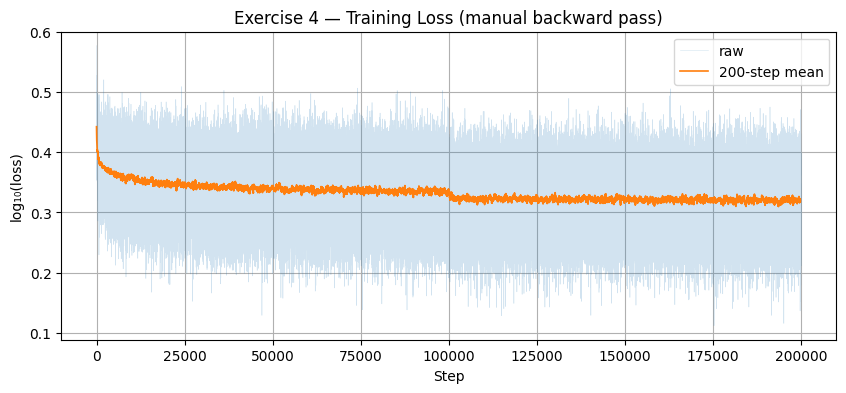

In [18]:
smooth = torch.tensor(lossi).unfold(0, 200, 1).mean(1)

plt.figure(figsize=(10, 4))
plt.plot(lossi,  alpha=0.2, lw=0.4, label='raw')
plt.plot(smooth, lw=1.2,   label='200-step mean')
plt.xlabel('Step')
plt.ylabel('log\u2081\u2080(loss)')
plt.title('Exercise 4 — Training Loss (manual backward pass)')
plt.legend()
plt.grid(True)
plt.show()

## 7. Batch Norm Calibration

Because training used per-batch statistics, we need to compute the **global**
mean and variance over the entire training set for correct inference.
These replace the per-batch stats when evaluating or generating.

In [19]:
with torch.no_grad():
    emb    = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact_all = embcat @ W1 + b1
    bnmean = hpreact_all.mean(0, keepdim=True)            # global mean
    bnvar  = hpreact_all.var(0, keepdim=True, unbiased=True)  # global variance

print('Calibration complete.')
print(f'  bnmean range: [{bnmean.min().item():.3f}, {bnmean.max().item():.3f}]')
print(f'  bnvar  range: [{bnvar.min().item():.3f},  {bnvar.max().item():.3f}]')

Calibration complete.
  bnmean range: [-2.827, 3.292]
  bnvar  range: [1.509,  8.593]


## 8. Evaluation

Using the calibrated BN statistics, evaluate the cross-entropy loss on all splits.

Expected results: **train ≈ 2.07, val ≈ 2.12**

In [20]:
@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb    = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # Use calibrated global BN stats for inference
    hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5) ** -0.5 + bnbias
    h      = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss   = F.cross_entropy(logits, y)
    print(f'{split:6s} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train  loss: 2.0720


val    loss: 2.1099


## 9. Name Generation

Sample names autoregressively using the model trained with our manual backward pass.
The forward pass is identical to the one used for evaluation — calibrated BN stats,
no autograd.

In [21]:
g_sample = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out     = []
    context = [0] * block_size

    while True:
        # Forward pass (inference mode — calibrated BN stats)
        emb     = C[torch.tensor([context])]         # (1, block_size, n_embd)
        embcat  = emb.view(emb.shape[0], -1)
        hpreact = embcat @ W1 + b1
        hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5) ** -0.5 + bnbias
        h       = torch.tanh(hpreact)
        logits  = h @ W2 + b2

        probs = F.softmax(logits, dim=1)
        ix    = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out[:-1]))

carmahzato
harli
jari
reity
skanden
jazonel
deliah
jareei
nellara
chaiivon
leigh
ham
joce
quinthorline
livani
waythoniearynix
kaellinsley
dae
iia
gian


In [22]:
# ── MLflow: log params, metrics, and model checkpoint ────────────────────────
import torch

@torch.no_grad()
def _eval(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    emb     = C[x]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5) ** -0.5 + bnbias
    h       = torch.tanh(hpreact)
    logits  = h @ W2 + b2
    return F.cross_entropy(logits, y).item()

train_loss = _eval('train')
val_loss   = _eval('val')

mlflow.log_params({
    'n_embd':     n_embd,
    'n_hidden':   n_hidden,
    'block_size': block_size,
    'max_steps':  max_steps,
    'batch_size': batch_size,
    'vocab_size': vocab_size,
    'backprop':   'manual_fused',
})
mlflow.log_metric('train_loss', train_loss)
mlflow.log_metric('val_loss',   val_loss)

ckpt_path = 'checkpoints/part4_backprop.pt'
torch.save({
    'C': C.data, 'W1': W1.data, 'b1': b1.data,
    'W2': W2.data, 'b2': b2.data,
    'bngain': bngain.data, 'bnbias': bnbias.data,
    'bnmean': bnmean, 'bnvar': bnvar,
    'stoi': stoi, 'itos': itos,
    'n_embd': n_embd, 'n_hidden': n_hidden, 'block_size': block_size,
}, ckpt_path)
mlflow.log_artifact(ckpt_path)

mlflow.end_run()
print(f'MLflow run complete  train={train_loss:.4f}  val={val_loss:.4f}  ckpt={ckpt_path}')

MLflow run complete  train=2.0720  val=2.1099  ckpt=checkpoints/part4_backprop.pt
